# High-cardinality and categorical variables, with TabPFN

A categorical column forces a choice a gradient-boosting practitioner makes on reflex: how do you turn
the labels into numbers? Ordinal codes, one-hot columns, frequency counts, a target statistic, or the
model's own native handling. This notebook walks that familiar checklist, then shows that for TabPFN the
choice mostly stops mattering, and isolates the one place it still does. Every experiment is a small
construction plus one real dataset, so the behaviour is real but the setup stays easy to read.

Everything here is the local `tabpfn` package (8.0.3, v3 default checkpoint), not the hosted API. That
distinction turns out to matter for text, and beat 4 says exactly where.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("fivethirtyeight")
from tqdm import tqdm
from tabulate import tabulate

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.datasets import fetch_openml

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from tabpfn import TabPFNClassifier

def printdf(df, nrows=10, showindex=True):
    print(tabulate(df.head(nrows), headers="keys", tablefmt="psql", showindex=showindex))

def auc(model, X_train, y_train, X_test, y_test):
    """Fit on train, return ROC AUC on the positive-class probability for test."""
    model.fit(X_train, y_train)
    return roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

## 1. The familiar checklist

You encode a categorical by what it represents. The practitioner's map, the way the CardoAI course
teaches it, with every mapping learned on the training split only:

- **Ordinal**: integers `0..N-1`. For genuinely ordered categories, or for tree models. Watch the fake
  order it injects on nominals (is Japan greater than Brazil in any real sense?).
- **One-hot**: one binary column per level. For low or medium cardinality nominals, especially linear and
  distance-based models. Watch the blow-up on high cardinality.
- **Frequency**: replace each level by how often it appears in train. A compact numeric for high
  cardinality. Watch collisions: two levels with the same count get the same number.
- **Target**: replace each level by a statistic of the target. For high cardinality that carries signal.
  Watch leakage: learn it on train only, out-of-fold for the training rows, and smooth rare levels.
- **Native**: hand the raw column to a model that has its own categorical handling (CatBoost, LightGBM,
  XGBoost).

The same four encodings, side by side on a toy column, so the shapes are concrete:

In [2]:
toy = pd.DataFrame({
    "country": ["Germany", "Brazil", "Japan", "Canada", "Brazil", "Germany", "Germany", "Japan"],
    "y":       [1, 0, 0, 1, 0, 1, 1, 0],
})

ordinal_codes = OrdinalEncoder().fit_transform(toy[["country"]]).ravel().astype(int)
onehot = OneHotEncoder(sparse_output=False).fit_transform(toy[["country"]])
onehot_names = [f"oh_{c}" for c in sorted(toy["country"].unique())]
frequency = toy["country"].map(toy["country"].value_counts(normalize=True))
target_mean = toy["country"].map(toy.groupby("country")["y"].mean())   # in-sample, for illustration only

shown = toy.copy()
shown["ordinal"] = ordinal_codes
shown["frequency"] = frequency.round(2)
shown["target_mean"] = target_mean.round(2)
printdf(pd.concat([shown, pd.DataFrame(onehot, columns=onehot_names).astype(int)], axis=1), nrows=8)

+----+-----------+-----+-----------+-------------+---------------+-------------+-------------+--------------+------------+
|    | country   |   y |   ordinal |   frequency |   target_mean |   oh_Brazil |   oh_Canada |   oh_Germany |   oh_Japan |
|----+-----------+-----+-----------+-------------+---------------+-------------+-------------+--------------+------------|
|  0 | Germany   |   1 |         2 |        0.38 |             1 |           0 |           0 |            1 |          0 |
|  1 | Brazil    |   0 |         0 |        0.25 |             0 |           1 |           0 |            0 |          0 |
|  2 | Japan     |   0 |         3 |        0.25 |             0 |           0 |           0 |            0 |          1 |
|  3 | Canada    |   1 |         1 |        0.12 |             1 |           0 |           1 |            0 |          0 |
|  4 | Brazil    |   0 |         0 |        0.25 |             0 |           1 |           0 |            0 |          0 |
|  5 | Germany  

Each method trades off differently: ordinal spends one column but invents an order, one-hot keeps the
nominal structure but spends a column per level, frequency stays compact but can collide, and target is
the most informative but leaks if you do not cross-fit it. The `target_mean` above is computed in-sample
purely to show the shape; the experiment below uses the out-of-fold version.

## 2. What TabPFN does to that checklist

You pass the raw column. TabPFN inspects each column and assigns it a modality on its own, so the
encoding decision moves from you to the model. Here is the decision on four columns at once:

In [3]:
# TabPFN reads each column's modality from the ORIGINAL values, before any cast
# (tabpfn/preprocessing/modality_detection.py, _detect_feature_modality): a string with
# <=30 unique values is categorical, more than 30 is text, numeric-looking stays numerical.
rng = np.random.RandomState(0)
n = 400
demo = pd.DataFrame({
    "low_card_string":  [f"city_{i}" for i in rng.randint(0, 10, n)],    # 10 string levels
    "high_card_string": [f"id_{i}"   for i in rng.randint(0, 120, n)],   # 120 string levels
    "integer_code":     rng.randint(0, 50, n).astype(float),            # 50 numeric codes
    "true_numeric":     rng.normal(size=n),
})
clf = TabPFNClassifier(random_state=0)
clf.fit(demo, (rng.random(n) < 0.5).astype(int))

for column, feature in zip(demo.columns, clf.inferred_feature_schema_.features):
    print(f"{column:18} -> {feature.modality.value}")

low_card_string    -> categorical
high_card_string   -> text
integer_code       -> numerical
true_numeric       -> numerical


The rule in one breath: a string with 30 or fewer unique values is **categorical**, more than 30 is
**text**, and anything that looks numeric (including integer codes) is **numerical**. So the menu
collapses to a single row, "pass it raw".

The modality is only a label, though. Whatever it is, the first transform TabPFN applies to the data is
the same: it casts every non-numeric column to integers. `clean_data` (`tabpfn/preprocessing/clean.py`)
runs one shared ordinal encoder (`get_ordinal_encoder`, in
`tabpfn/preprocessing/steps/preprocessing_helpers.py`) over the string and category columns before the
network sees a single value. We can run that exact encoder ourselves:

In [4]:
from tabpfn.preprocessing.steps.preprocessing_helpers import get_ordinal_encoder

# The same ordinal encoder clean_data uses. convert_dtypes() is the cast clean_data does first
# (object -> string), so the two string columns are picked up and turned into integer codes, while
# the numeric columns pass straight through.
codes = get_ordinal_encoder().fit_transform(demo.convert_dtypes())
peek = pd.DataFrame({
    "low_card_string":  demo["low_card_string"].values,  "code (categorical)": codes[:, 0].astype(int),
    "high_card_string": demo["high_card_string"].values, "code (text)":        codes[:, 1].astype(int),
})
printdf(peek, nrows=6)

+----+-------------------+----------------------+--------------------+---------------+
|    | low_card_string   |   code (categorical) | high_card_string   |   code (text) |
|----+-------------------+----------------------+--------------------+---------------|
|  0 | city_5            |                    5 | id_47              |            57 |
|  1 | city_0            |                    0 | id_10              |             2 |
|  2 | city_3            |                    3 | id_109             |            11 |
|  3 | city_3            |                    3 | id_104             |             6 |
|  4 | city_7            |                    7 | id_94              |           109 |
|  5 | city_9            |                    9 | id_91              |           106 |
+----+-------------------+----------------------+--------------------+---------------+


The high-cardinality string got no special treatment: it became integer codes exactly like the
low-cardinality one. The modality (categorical or text) only decides what happens to those codes next,
not whether they become codes. The open question is whether handing TabPFN the raw column, and letting
it do this, is as good as the careful encoding you would have reached for. Beat 3 measures it.

## 3. One measured result

The question: does the encoding choice change accuracy, and does that depend on the model and on the
cardinality? The construction is deliberately narrow so the answer is clean. One nominal categorical `g`
with `K` levels (skewed frequencies, so rare levels exist) whose **only** signal is its per-level mean,
no order, plus two pure-noise numerics. We sweep `K` and compare the five representations across the full
roster, AUC over three seeds.

Two honest caveats stated up front. The signal is linear in the levels, which flatters a one-hot logistic
regression (it is near the Bayes model here), so do not read the LogReg-onehot number as general. And
frequency is independent of the signal by construction, so it is a floor that hurts every model, not a
verdict on frequency encoding; the trend chart therefore excludes it and the full table keeps it.

In [5]:
def make_data(K, seed, n=4000, n_noise=2):
    """Binary task whose only signal is the per-level mean of one nominal categorical g
    with K levels (skewed Zipf frequencies, no real order), plus n_noise pure-noise numerics."""
    rng = np.random.RandomState(seed)
    p = 1.0 / np.arange(1, K + 1)
    p = p / p.sum()
    g = rng.choice(K, size=n, p=p)
    beta = rng.normal(0.0, 1.5, size=K)                       # per-level log-odds, no order
    y = (rng.random(n) < 1.0 / (1.0 + np.exp(-beta[g]))).astype(int)
    X = pd.DataFrame({"g": [f"lvl_{v}" for v in g]})
    for j in range(n_noise):
        X[f"x{j}"] = rng.normal(size=n)
    half = n // 2
    return (X.iloc[:half].reset_index(drop=True), X.iloc[half:].reset_index(drop=True), y[:half], y[half:])

def rep_ordinal(train, test):
    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    a, b = train.copy(), test.copy()
    a["g"] = enc.fit_transform(train[["g"]]).ravel()
    b["g"] = enc.transform(test[["g"]]).ravel()
    return a, b

def rep_onehot(train, test):
    enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    A, B = enc.fit_transform(train[["g"]]), enc.transform(test[["g"]])
    names = [f"g_{c}" for c in enc.categories_[0]]
    a = pd.concat([train.drop(columns="g"), pd.DataFrame(A, columns=names)], axis=1)
    b = pd.concat([test.drop(columns="g"), pd.DataFrame(B, columns=names)], axis=1)
    return a, b

def rep_frequency(train, test):
    freq = train["g"].value_counts(normalize=True)
    a, b = train.copy(), test.copy()
    a["g"] = train["g"].map(freq).fillna(0.0)
    b["g"] = test["g"].map(freq).fillna(0.0)
    return a, b

def rep_target(train, test, y_train):
    enc = TargetEncoder(smooth="auto", cv=5)                  # cross-fitted on train, leakage-safe
    a, b = train.copy(), test.copy()
    a["g"] = enc.fit_transform(train[["g"]], y_train).ravel()
    b["g"] = enc.transform(test[["g"]]).ravel()
    return a, b

In [6]:
def make_model(name, seed):
    if name == "logreg":       return Pipeline([("scale", StandardScaler()), ("lr", LogisticRegression(max_iter=2000))])
    if name == "randomforest": return RandomForestClassifier(n_estimators=300, random_state=seed, n_jobs=-1)
    if name == "xgboost":      return XGBClassifier(tree_method="hist", random_state=seed, verbosity=0)
    if name == "lightgbm":     return LGBMClassifier(verbose=-1, random_state=seed)
    if name == "catboost":     return CatBoostClassifier(verbose=0, random_state=seed)
    if name == "tabpfn":       return TabPFNClassifier(random_state=seed)

def as_native(name, train, test, seed):
    """Hand the raw column to a model that has its own categorical handling."""
    a, b = train.copy(), test.copy()
    if name == "tabpfn":
        return a, b, make_model("tabpfn", seed)              # raw string, TabPFN picks the modality
    if name == "catboost":
        a["g"], b["g"] = a["g"].astype(str), b["g"].astype(str)
        return a, b, CatBoostClassifier(verbose=0, random_state=seed, cat_features=[a.columns.get_loc("g")])
    levels = pd.api.types.union_categoricals([a["g"].astype("category"), b["g"].astype("category")]).categories
    a["g"] = pd.Categorical(a["g"], categories=levels)
    b["g"] = pd.Categorical(b["g"], categories=levels)
    if name == "lightgbm": return a, b, make_model("lightgbm", seed)
    if name == "xgboost":  return a, b, XGBClassifier(tree_method="hist", enable_categorical=True, random_state=seed, verbosity=0)

ENCODERS = {"ordinal": rep_ordinal, "onehot": rep_onehot, "frequency": rep_frequency, "target": rep_target}
MODELS = ["logreg", "randomforest", "xgboost", "lightgbm", "catboost", "tabpfn"]
NATIVE = ["tabpfn", "catboost", "lightgbm", "xgboost"]

def run_sweep(cardinalities, seeds):
    rows = []
    for K in tqdm(cardinalities, desc="cardinality"):
        for seed in seeds:
            train, test, y_train, y_test = make_data(K, seed)
            for rep_name, rep_fn in ENCODERS.items():
                a, b = rep_fn(train, test, y_train) if rep_name == "target" else rep_fn(train, test)
                for model_name in MODELS:
                    score = auc(make_model(model_name, seed), a, y_train, b, y_test)
                    rows.append(dict(K=K, seed=seed, model=model_name, rep=rep_name, auc=score))
            for model_name in NATIVE:
                a, b, clf = as_native(model_name, train, test, seed)
                clf.fit(a, y_train)
                rows.append(dict(K=K, seed=seed, model=model_name, rep="native",
                                 auc=roc_auc_score(y_test, clf.predict_proba(b)[:, 1])))
    return pd.DataFrame(rows)

synth = run_sweep([10, 40, 120], [0, 1, 2])
order = ["native", "ordinal", "onehot", "frequency", "target"]
print("Mean AUC at K=120 (high cardinality):")
printdf(synth[synth.K == 120].pivot_table(index="model", columns="rep", values="auc")[order].round(4))

cardinality:   0%|                                                                                                                                                  | 0/3 [00:00<?, ?it/s]

cardinality:  33%|██████████████████████████████████████████████                                                                                            | 1/3 [01:01<02:02, 61.49s/it]

cardinality:  67%|████████████████████████████████████████████████████████████████████████████████████████████                                              | 2/3 [02:07<01:04, 64.08s/it]

cardinality: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [03:20<00:00, 68.11s/it]

cardinality: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [03:20<00:00, 66.76s/it]

Mean AUC at K=120 (high cardinality):
+--------------+----------+-----------+----------+-------------+----------+
| model        |   native |   ordinal |   onehot |   frequency |   target |
|--------------+----------+-----------+----------+-------------+----------|
| catboost     |   0.7791 |    0.7525 |   0.775  |      0.7363 |   0.7753 |
| lightgbm     |   0.747  |    0.7402 |   0.7116 |      0.7206 |   0.7599 |
| logreg       | nan      |    0.5887 |   0.7871 |      0.5385 |   0.7879 |
| randomforest | nan      |    0.7132 |   0.7553 |      0.7048 |   0.7615 |
| tabpfn       |   0.7835 |    0.7835 |   0.7918 |      0.758  |   0.7869 |
| xgboost      |   0.7444 |    0.736  |   0.7573 |      0.7106 |   0.7437 |
+--------------+----------+-----------+----------+-------------+----------+


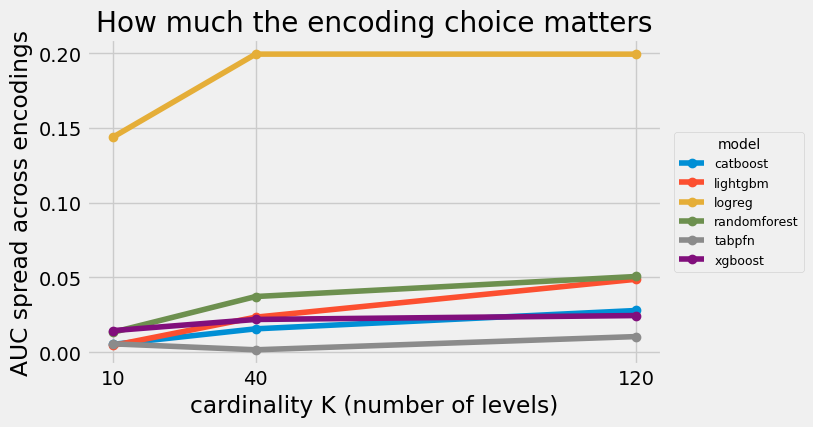

Representation spread (max minus min AUC across the four encodings):
+--------------+--------+--------+--------+
| model        |     10 |     40 |    120 |
|--------------+--------+--------+--------|
| catboost     | 0.0053 | 0.0156 | 0.0279 |
| lightgbm     | 0.0045 | 0.0234 | 0.0488 |
| logreg       | 0.1438 | 0.1993 | 0.1992 |
| randomforest | 0.0133 | 0.0372 | 0.0506 |
| tabpfn       | 0.0056 | 0.0016 | 0.0105 |
| xgboost      | 0.0144 | 0.0219 | 0.0245 |
+--------------+--------+--------+--------+


In [7]:
# how much the encoding choice moves AUC, per model and cardinality (excluding the frequency floor)
four = synth[synth.rep != "frequency"]
spread = (four.groupby(["model", "K", "seed"]).auc.agg(lambda v: v.max() - v.min())
              .groupby(["model", "K"]).mean().unstack("K"))

fig, ax = plt.subplots(figsize=(8.5, 4.5))
for model_name in spread.index:
    ax.plot(spread.columns, spread.loc[model_name].values, marker="o", label=model_name)
ax.set_xlabel("cardinality K (number of levels)")
ax.set_ylabel("AUC spread across encodings")
ax.set_title("How much the encoding choice matters")
ax.set_xticks(list(spread.columns))
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), title="model", fontsize=9, title_fontsize=10)
fig.tight_layout()
plt.show()

print("Representation spread (max minus min AUC across the four encodings):")
printdf(spread.round(4))

Read the chart top to bottom. TabPFN's line is flat and lowest, and the gap is clearest at high
cardinality: the encoding choice barely moves it, while every classic model's line climbs as K grows.
They climb roughly in the order a practitioner would guess, LogReg by far the most encoding-dependent,
then the tree models, with RandomForest the most representation-sensitive of those once the cardinality
is high. TabPFN-raw also sits at the top of the AUC table, so you reach top-tier accuracy with none of
the choices the other models force.

The synthetic result is structural but it is still one construction. The decisive check is real
high-cardinality data, where the levels are genuine identifiers, not a signal we planted. Amazon Employee
Access is the canonical case: nine integer-ID columns, some with thousands of levels.

In [8]:
data = fetch_openml(data_id=4135, as_frame=True)              # Amazon Employee Access
Xfull, yfull = data.data.copy(), data.target.astype(int).values
cardinalities = {c: int(Xfull[c].nunique()) for c in Xfull.columns}
print("rows", len(Xfull), "| features", Xfull.shape[1], "| positive rate", round(float(yfull.mean()), 3))
print("per-column cardinality:", cardinalities)
print("one-hot would create", sum(cardinalities.values()), "columns, so we omit it here")

rows 32769 | features 9 | positive rate 0.942
per-column cardinality: {'RESOURCE': 7518, 'MGR_ID': 4243, 'ROLE_ROLLUP_1': 128, 'ROLE_ROLLUP_2': 177, 'ROLE_DEPTNAME': 449, 'ROLE_TITLE': 343, 'ROLE_FAMILY_DESC': 2358, 'ROLE_FAMILY': 67, 'ROLE_CODE': 343}
one-hot would create 15626 columns, so we omit it here


In [9]:
cols = list(Xfull.columns)

def amazon_subsample(seed, n=12000):
    rng = np.random.RandomState(seed)
    idx = rng.permutation(len(Xfull))[:n]
    Xs, ys = Xfull.iloc[idx].reset_index(drop=True), yfull[idx]
    half = n // 2
    return Xs.iloc[:half].reset_index(drop=True), Xs.iloc[half:].reset_index(drop=True), ys[:half], ys[half:]

def amazon_ordinal(train, test):
    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    return pd.DataFrame(enc.fit_transform(train), columns=cols), pd.DataFrame(enc.transform(test), columns=cols)

def amazon_frequency(train, test):
    a, b = pd.DataFrame(), pd.DataFrame()
    for c in cols:
        freq = train[c].value_counts(normalize=True)
        a[c] = train[c].map(freq).fillna(0.0).values
        b[c] = test[c].map(freq).fillna(0.0).values
    return a, b

def amazon_target(train, test, y_train):
    enc = TargetEncoder(smooth="auto", cv=5)
    return pd.DataFrame(enc.fit_transform(train, y_train), columns=cols), pd.DataFrame(enc.transform(test), columns=cols)

def amazon_native(name, train, test, seed):
    a, b = train.copy(), test.copy()
    if name == "tabpfn":
        return a, b, make_model("tabpfn", seed)
    if name == "catboost":
        return a.astype(str), b.astype(str), CatBoostClassifier(verbose=0, random_state=seed, cat_features=list(range(len(cols))))
    for c in cols:
        levels = pd.api.types.union_categoricals([a[c].astype("category"), b[c].astype("category")]).categories
        a[c] = pd.Categorical(a[c], categories=levels)
        b[c] = pd.Categorical(b[c], categories=levels)
    if name == "lightgbm": return a, b, make_model("lightgbm", seed)
    if name == "xgboost":  return a, b, XGBClassifier(tree_method="hist", enable_categorical=True, random_state=seed, verbosity=0)

amazon_encoders = {"ordinal": amazon_ordinal, "frequency": amazon_frequency, "target": amazon_target}
rows = []
for seed in tqdm([0, 1, 2], desc="seed"):
    train, test, y_train, y_test = amazon_subsample(seed)
    for rep_name, rep_fn in amazon_encoders.items():
        a, b = rep_fn(train, test, y_train) if rep_name == "target" else rep_fn(train, test)
        for model_name in MODELS:
            try:
                score = auc(make_model(model_name, seed), a, y_train, b, y_test)
            except Exception:
                score = np.nan
            rows.append(dict(seed=seed, model=model_name, rep=rep_name, auc=score))
    for model_name in NATIVE:
        a, b, clf = amazon_native(model_name, train, test, seed)
        clf.fit(a, y_train)
        rows.append(dict(seed=seed, model=model_name, rep="native", auc=roc_auc_score(y_test, clf.predict_proba(b)[:, 1])))

amazon = pd.DataFrame(rows)
amazon_table = amazon.pivot_table(index="model", columns="rep", values="auc")[["native", "ordinal", "frequency", "target"]]
print("Amazon: mean AUC by model and representation (one-hot omitted):")
printdf(amazon_table.round(4))

seed:   0%|                                                                                                                                                         | 0/3 [00:00<?, ?it/s]

seed:  33%|████████████████████████████████████████████████▎                                                                                                | 1/3 [00:39<01:19, 39.57s/it]

seed:  67%|████████████████████████████████████████████████████████████████████████████████████████████████▋                                                | 2/3 [01:18<00:39, 39.33s/it]

seed: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [01:57<00:00, 39.24s/it]

seed: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [01:57<00:00, 39.29s/it]

Amazon: mean AUC by model and representation (one-hot omitted):
+--------------+----------+-----------+-------------+----------+
| model        |   native |   ordinal |   frequency |   target |
|--------------+----------+-----------+-------------+----------|
| catboost     |   0.7809 |    0.6692 |      0.7218 |   0.7276 |
| lightgbm     |   0.751  |    0.674  |      0.7377 |   0.7012 |
| logreg       | nan      |    0.5921 |      0.5849 |   0.763  |
| randomforest | nan      |    0.7433 |      0.7497 |   0.7357 |
| tabpfn       |   0.7486 |    0.7486 |      0.7614 |   0.7633 |
| xgboost      |   0.7244 |    0.6871 |      0.7389 |   0.6783 |
+--------------+----------+-----------+-------------+----------+


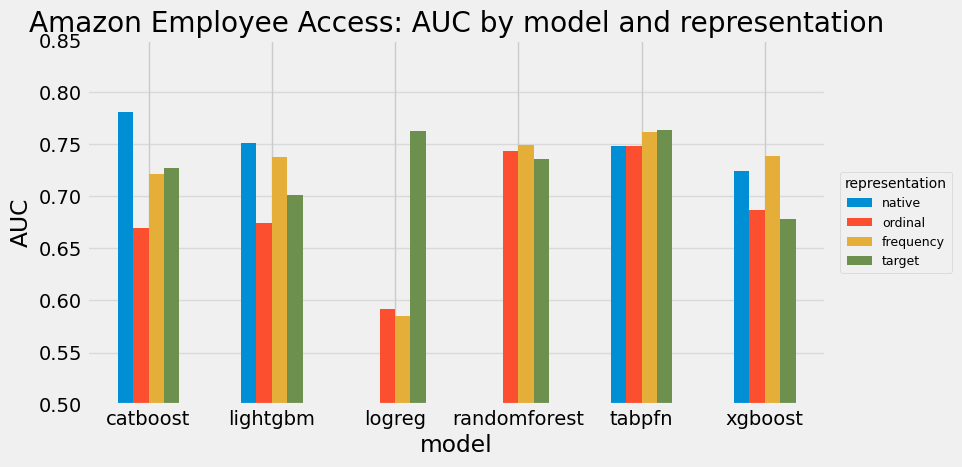

In [10]:
ax = amazon_table.plot(kind="bar", figsize=(8.5, 4.5))
ax.set_ylabel("AUC")
ax.set_xlabel("model")
ax.set_ylim(0.5, 0.85)
ax.set_yticks(np.arange(0.5, 0.86, 0.05))
ax.set_axisbelow(True)
ax.grid(axis="y", alpha=0.6)
ax.set_title("Amazon Employee Access: AUC by model and representation")
ax.legend(title="representation", loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=9, title_fontsize=10)
plt.xticks(rotation=0)
plt.show()

The headline survives on real data: TabPFN has the smallest spread across representations, the bars
within its group are nearly level. But notice the honest twist that keeps this from being a TabPFN sales
pitch. The single best bar in the whole chart is CatBoost on its native path, and it beats TabPFN by a
clear margin. CatBoost owns both the best bar and one of the worst: it is the most representation-sensitive
model with a native path, so feeding it ordinal codes instead of declaring the categoricals collapses it
toward the base rate. The expertise to know "use CatBoost native, never ordinal-encode for it" is exactly
the decision TabPFN removes. The next section is why.

## 4. Deep dive: what the local package actually does

The collapse and the flat line are both preprocessing, not magic, and they are short enough to read. In
`tabpfn` 8.0.3 the modality of each column is decided in `tabpfn/preprocessing/modality_detection.py`
(`_detect_feature_modality`) against three constants in `tabpfn/inference_config.py`:

```
MAX_UNIQUE_FOR_CATEGORICAL_FEATURES = 30
MIN_UNIQUE_FOR_NUMERICAL_FEATURES   = 4
MIN_NUMBER_SAMPLES_FOR_CATEGORICAL_INFERENCE = 100
```

The decision:

- A numeric-looking column stays NUMERICAL unless you declare it categorical and it has 30 or fewer
  unique values, or it has fewer than 4 unique values with more than 100 rows. So integer-coded
  categoricals (risk grades, zip prefixes) are read as numbers by default.
- A string or category column with 30 or fewer unique values is CATEGORICAL, otherwise TEXT. The string
  branch never consults your `categorical_features_indices`, so the 30 cap is hard: you cannot force a
  7000-level column to be categorical.

### What a "text" column does locally, and why the API differs

This is the part worth knowing. Text is not a real pathway in the local package. In
`tabpfn/preprocessing/clean.py` (`clean_data`), every non-numeric column, category and string alike, is
ordinal-encoded to integer codes by one shared encoder (`get_ordinal_encoder` in
`tabpfn/preprocessing/steps/preprocessing_helpers.py`), and the whole frame is cast to float. The only
thing separating a categorical from a text column afterward is bookkeeping: every later step asks the
schema for `indices_for(FeatureModality.CATEGORICAL)` (in `tabpfn/inference.py`, the categorical-encode
step, the distribution-reshape step) and nothing ever asks for the text indices.

So a high-cardinality string becomes arbitrary integer codes handed to the model as a plain numeric
feature. The string content is gone the moment it is coded; there is no semantic understanding at all.
Per the Prior Labs FAQ, the hosted API does the opposite, it detects text features and embeds their
meaning. Same column: meaning through the API, identity only through the local package.

That is exactly what our experiment ran into, and we can see it directly. Our high-cardinality `lvl_*`
labels route to text, which is the same as ordinal-encoding them, so for TabPFN raw and ordinal should
land on top of each other:

In [11]:
train, test, y_train, y_test = make_data(120, 0)
raw_text = auc(TabPFNClassifier(random_state=0), train, y_train, test, y_test)   # g is a high-card string -> text
a, b = rep_ordinal(train, test)
ordinal_codes = auc(TabPFNClassifier(random_state=0), a, y_train, b, y_test)     # g is integer codes -> numerical
print(f"TabPFN, raw high-card string (text modality)  {raw_text:.4f}")
print(f"TabPFN, ordinal integer codes (numerical)     {ordinal_codes:.4f}")

TabPFN, raw high-card string (text modality)  0.7440
TabPFN, ordinal integer codes (numerical)     0.7440


### Why an arbitrary integer order helps TabPFN but breaks a boosted tree

The same input, an arbitrary integer code, is read very differently by the two model families, and that
is the whole story of the chart. A gradient-boosted tree makes axis-aligned threshold splits. On a column
of arbitrary codes (`lvl_5 < lvl_6 < ...`) a threshold only separates one contiguous run of codes from
another, which is meaningless for a nominal category. Isolating a single level costs about two splits, so
across thousands of levels the tree runs out of budget and falls toward the base rate. Native CatBoost
avoids this by encoding each level with ordered target statistics (a leakage-safe per-level target mean);
ordinal-as-numeric throws that machinery away, and LightGBM and XGBoost collapse the same way.

TabPFN is not splitting on the axis. It is a transformer reading the actual values in context, so two
rows that share a code are simply two rows with an equal feature value, and it can learn a non-monotonic
response per code. An arbitrary order does not trap it. The three numbers below are the whole mechanism:

In [12]:
train, test, y_train, y_test = amazon_subsample(0)
a, b, catboost_native_clf = amazon_native("catboost", train, test, 0)
catboost_native_clf.fit(a, y_train)
catboost_native = roc_auc_score(y_test, catboost_native_clf.predict_proba(b)[:, 1])

a_ord, b_ord = amazon_ordinal(train, test)
catboost_ordinal = auc(CatBoostClassifier(verbose=0, random_state=0), a_ord, y_train, b_ord, y_test)
tabpfn_ordinal = auc(TabPFNClassifier(random_state=0), a_ord, y_train, b_ord, y_test)

print(f"CatBoost, native categorical      {catboost_native:.4f}")
print(f"CatBoost, ordinal-as-numeric      {catboost_ordinal:.4f}")
print(f"TabPFN,   ordinal-as-numeric      {tabpfn_ordinal:.4f}")

CatBoost, native categorical      0.7877
CatBoost, ordinal-as-numeric      0.6825
TabPFN,   ordinal-as-numeric      0.7511


### The watch-items are still yours, even when they are not the model's

- **Target-encoding leakage** is real, and the experiment respects it: the encoding is cross-fitted on
  the training rows (`TargetEncoder(cv=5)`), then applied to test. Fit it in-sample and you leak the
  label. TabPFN does not need target encoding, so it sidesteps the trap, but you do not when you reach for
  it elsewhere.
- **Frequency collisions**: two levels with the same count get the same number even when their target
  behaviour differs. In our construction frequency is independent of the signal by design, so it is a
  floor that hurts every model; on data where rare levels behave differently it can carry real signal.
- **Unseen categories at predict time**: for a categorical column the per-ensemble encoder maps an unseen
  level to NaN (`unknown_value=np.nan`), which flows into the same native missing-value path as the
  missing-values notebook. For a text column the unseen code is the integer `-1`, treated as a number.
  Either way you do not hand-handle it.

### Honest limits

TabPFN is not the top score on Amazon; CatBoost with native handling is, by a clear margin. The trade is
real: CatBoost buys peak accuracy if you know to use its native path and never ordinal-encode for it,
while TabPFN buys you out of the decision and lands competitively with no representation tuning. The
roster runs on default hyperparameters, so the exact GBM gaps would shift with tuning, and the synthetic
signal is linear in the levels, which flatters the one-hot logistic regression. None of that moves the
flat TabPFN line, which is the result the chapter rests on.

## Takeaways

The categorical checklist, re-answered for the local TabPFN package:

- Ordinal, one-hot, frequency, target: for TabPFN these land within a few thousandths of each other at
  every cardinality we tried. Pass the column raw.
- The 30-unique cap decides categorical versus text, and it is hard. Integer codes read as numbers.
- Text is identity only in the local package (ordinal codes, no semantics). If the meaning of the text
  matters, that lives in the hosted API, not here.
- An arbitrary integer order is harmless to TabPFN and ruinous to a boosted tree forced to read it as
  numeric. That one fact explains both the flat TabPFN line and the CatBoost collapse.
- The work you still own: leakage-safe target encoding when you use it, and knowing that a model's best
  categorical path (CatBoost native) is a choice TabPFN takes off your plate.